# Experiment: LLM Trust Labeling + Probabilistic Graph

This notebook implements:
1. LLM labeling via Ollama for trust metrics: `claim_trust_score`, `signal_trust_score`, `heuristic_pressure_score`, `competence_score`, `benevolence_score`, `integrity_score`, `predictability_score`.
2. Phase A validation on fake-news data with ground-truth labels.
3. Probabilistic graph modeling (naive Bayesian graph) and logistic baseline.
4. Phase B application on product listings (no truth labels) to produce trust-risk indices.


In [1]:
%pip install -q --upgrade pandas numpy scikit-learn tqdm datasets matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Run controls (edit this for each new run)
RUN_SAMPLE_SIZES = {
    'phase_a_target_rows': 240,
    'phase_b_target_rows': 300,
}
RUN_LIMITS = {
    # None means no per-phase call cap (labels all selected rows)
    'max_calls_per_phase': None,
}
RUN_ARCHIVE = {
    'enabled': True,
    'archive_folder_name': 'llm_trust_graph_archive',
}
print('Run sample sizes:', RUN_SAMPLE_SIZES)
print('Run limits:', RUN_LIMITS)
print('Archive settings:', RUN_ARCHIVE)


Run sample sizes: {'phase_a_target_rows': 240, 'phase_b_target_rows': 300}
Run limits: {'max_calls_per_phase': None}
Archive settings: {'enabled': True, 'archive_folder_name': 'llm_trust_graph_archive'}


In [3]:
# Archive existing artifacts (safety snapshot before new run)
from datetime import datetime
import shutil
from pathlib import Path
cwd = Path.cwd().resolve()
project_root_for_archive = None
for root in [cwd, *cwd.parents]:
    if (root / 'experiment_trust_fake_reviews').exists():
        project_root_for_archive = root
        break
if project_root_for_archive is None:
    raise FileNotFoundError('Could not locate project root containing experiment_trust_fake_reviews/.')
artifacts_dir_to_archive = project_root_for_archive / 'experiment_trust_fake_reviews' / 'artifacts' / 'llm_trust_graph'
archive_enabled = bool(globals().get('RUN_ARCHIVE', {}).get('enabled', True))
archive_folder_name = str(globals().get('RUN_ARCHIVE', {}).get('archive_folder_name', 'llm_trust_graph_archive'))
archive_root_dir = project_root_for_archive / 'experiment_trust_fake_reviews' / 'artifacts' / archive_folder_name
if not archive_enabled:
    print('Archiving disabled by RUN_ARCHIVE settings.')
elif not artifacts_dir_to_archive.exists() or not any(artifacts_dir_to_archive.iterdir()):
    print('No existing artifacts found to archive at:', artifacts_dir_to_archive)
else:
    run_info_path = artifacts_dir_to_archive / 'run_info.json'
    if run_info_path.exists():
        ts = run_info_path.stat().st_mtime
    else:
        ts = max(p.stat().st_mtime for p in artifacts_dir_to_archive.rglob('*') if p.is_file())
    stamp = datetime.fromtimestamp(ts).strftime('%Y%m%d_%H%M%S')
    archive_root_dir.mkdir(parents=True, exist_ok=True)
    archive_target = archive_root_dir / f'run_{stamp}'
    suffix = 1
    while archive_target.exists():
        archive_target = archive_root_dir / f'run_{stamp}_{suffix}'
        suffix += 1
    shutil.copytree(artifacts_dir_to_archive, archive_target)
    archived_files = sum(1 for p in archive_target.rglob('*') if p.is_file())
    print('Archived previous artifacts to:', archive_target)
    print('Archived file count:', archived_files)


Archived previous artifacts to: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph_archive/run_20260329_125310_2
Archived file count: 11


In [4]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Resolve project root without depending on trust_agent/ existing.
cwd = Path.cwd().resolve()
project_root = None
for root in [cwd, *cwd.parents]:
    if (root / 'experiment_trust_fake_reviews').exists():
        project_root = root
        break
if project_root is None:
    raise FileNotFoundError('Could not locate project root containing experiment_trust_fake_reviews/.')
import sys
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from experiment_trust_fake_reviews.llm_trust_graph_pipeline import (
    LabelingConfig,
    PhaseConfig,
    apply_phase_b_inference,
    build_label_prompt,
    label_dataframe_with_ollama,
    load_product_dataset,
    run_duplicate_label_check,
    run_ollama_label,
    run_phase_a_training,
    save_json,
)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 140)
project_root


PosixPath('/Users/lohzh/Desktop/cs3263-repo')

In [5]:
# Configuration
OLLAMA_MODEL = 'llama3.1:8b'
FAKE_REVIEWS_DATASET_PATH = project_root / 'data/raw/fake-reviews-dataset/fake reviews dataset.csv'
PRODUCT_DATASET_PATH = project_root / 'data/raw/amazon-product-data/dataset/train.csv'
# Reuse Phase B product LLM labels from original trust experiment artifacts when available
REUSE_PHASE_B_LABELS = True
REUSE_SOURCE_ARTIFACTS_DIR = project_root / 'experiment_trust' / 'artifacts' / 'llm_trust_graph'
REUSE_PHASE_B_SCORED_PATH = REUSE_SOURCE_ARTIFACTS_DIR / 'phase_b_scored.csv'
sample_sizes = globals().get('RUN_SAMPLE_SIZES', {})
run_limits = globals().get('RUN_LIMITS', {})
PHASE_A_TARGET_ROWS = int(sample_sizes.get('phase_a_target_rows', 120))
PHASE_B_TARGET_ROWS = int(sample_sizes.get('phase_b_target_rows', 150))
MAX_CALLS_PER_PHASE = run_limits.get('max_calls_per_phase', 120)  # None -> label all selected rows
RANDOM_STATE = 42
TEST_SIZE = 0.25
DUPLICATE_FRACTION = 0.1
MAX_OUTPUT_TOKENS = 220
CONTEXT_TOKENS = 1024
artifacts_dir = project_root / 'experiment_trust_fake_reviews' / 'artifacts' / 'llm_trust_graph'
artifacts_dir.mkdir(parents=True, exist_ok=True)
phase_a_cache = artifacts_dir / 'phase_a_labels.jsonl'
phase_b_cache = artifacts_dir / 'phase_b_labels.jsonl'
label_config = LabelingConfig(
    model=OLLAMA_MODEL,
    timeout_seconds=240,
    keepalive='10m',
    max_text_chars=1200,
    max_output_tokens=MAX_OUTPUT_TOKENS,
    context_tokens=CONTEXT_TOKENS,
    duplicate_fraction=DUPLICATE_FRACTION,
    random_state=RANDOM_STATE,
)
phase_config = PhaseConfig(
    target_rows=PHASE_A_TARGET_ROWS,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
print('Artifacts dir:', artifacts_dir)
print('Fake reviews dataset:', FAKE_REVIEWS_DATASET_PATH)
print('Reuse Phase B labels:', REUSE_PHASE_B_LABELS)
print('Reuse source path:', REUSE_PHASE_B_SCORED_PATH)
print('PHASE_A_TARGET_ROWS =', PHASE_A_TARGET_ROWS)
print('PHASE_B_TARGET_ROWS =', PHASE_B_TARGET_ROWS)
print('MAX_CALLS_PER_PHASE =', MAX_CALLS_PER_PHASE)


Artifacts dir: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph
Fake reviews dataset: /Users/lohzh/Desktop/cs3263-repo/data/raw/fake-reviews-dataset/fake reviews dataset.csv
Reuse Phase B labels: True
Reuse source path: /Users/lohzh/Desktop/cs3263-repo/experiment_trust/artifacts/llm_trust_graph/phase_b_scored.csv
PHASE_A_TARGET_ROWS = 240
PHASE_B_TARGET_ROWS = 300
MAX_CALLS_PER_PHASE = None


In [6]:
# Phase A: fake reviews dataset load (OR vs CG)
if not FAKE_REVIEWS_DATASET_PATH.exists():
    raise FileNotFoundError(f'Fake reviews dataset not found: {FAKE_REVIEWS_DATASET_PATH}')
raw_df = pd.read_csv(FAKE_REVIEWS_DATASET_PATH)
required_cols = {'text_', 'label'}
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise ValueError(f'Missing required fake review columns: {missing}')
phase_a_df = pd.DataFrame()
phase_a_df['text'] = raw_df['text_'].astype(str)
phase_a_df['label_raw'] = raw_df['label'].astype(str).str.strip().str.upper()
for col in ['category', 'rating']:
    if col in raw_df.columns:
        phase_a_df[col] = raw_df[col]
label_map = {
    'OR': 1,  # original human review -> truthful/original
    'CG': 0,  # computer-generated review -> synthetic/deceptive proxy
}
phase_a_df['label_truth'] = phase_a_df['label_raw'].map(label_map)
phase_a_df = phase_a_df[phase_a_df['label_truth'].isin([0, 1])].copy()
phase_a_df = phase_a_df[phase_a_df['text'].str.len() > 0].copy()
if PHASE_A_TARGET_ROWS > 0 and len(phase_a_df) > PHASE_A_TARGET_ROWS:
    per_class = max(1, PHASE_A_TARGET_ROWS // 2)
    sampled_parts = []
    for cls in [0, 1]:
        cls_df = phase_a_df[phase_a_df['label_truth'] == cls]
        n = min(per_class, len(cls_df))
        sampled_parts.append(cls_df.sample(n=n, random_state=RANDOM_STATE))
    phase_a_df = pd.concat(sampled_parts, ignore_index=True)
phase_a_df = phase_a_df.reset_index(drop=True)
phase_a_df['record_id'] = 'fake_reviews_' + phase_a_df.index.astype(str)
print('Phase A rows:', len(phase_a_df))
print('Phase A class distribution (0=CG, 1=OR):')
display(phase_a_df['label_truth'].value_counts(dropna=False))
display(phase_a_df[['record_id', 'label_raw', 'label_truth', 'text']].head(5))


Phase A rows: 240
Phase A class distribution (0=CG, 1=OR):


label_truth
0    120
1    120
Name: count, dtype: int64

,record_id,label_raw,label_truth,text
0,fake_reviews_0,CG,0,"I've replaced all my other fountain filters and the reservoir is still full. This is the only one I've seen that seems to work, and it i..."
1,fake_reviews_1,CG,0,"LT&T did not disappoint. We have the characters we love in this book, and the way the author is able to make them fit into the story. ..."
2,fake_reviews_2,CG,0,Both of my dogs (full grown) love the taste. I will keep this for the next couple of months. Great price! I will definitely order again!...
3,fake_reviews_3,CG,0,"First time user, glue last time. The only reason I gave it 4 stars is because I'm a self-proclaimed"
4,fake_reviews_4,CG,0,Klein is second to none. The quality and quality of Klein products is exceptional. Klein products are so affordable that I am not surp...


In [7]:
# Phase A: one-sample Ollama smoke test (before batch labeling)
sample_row = phase_a_df.iloc[0]
sample_text = str(sample_row['text'])[:label_config.max_text_chars]
sample_prompt = build_label_prompt(domain='fake_news', text=sample_text)
try:
    sample_label = run_ollama_label(
        prompt=sample_prompt,
        model=label_config.model,
        timeout_seconds=label_config.timeout_seconds,
        keepalive=label_config.keepalive,
        max_output_tokens=label_config.max_output_tokens,
        context_tokens=label_config.context_tokens,
    )
    print('One-sample label OK. Returned keys:', sorted(sample_label.keys()))
    display(pd.DataFrame([sample_label]))
except Exception as exc:
    print('One-sample label failed:', exc)
    raise


One-sample label OK. Returned keys: ['benevolence_bucket', 'benevolence_score', 'claim_trust_bucket', 'claim_trust_score', 'competence_bucket', 'competence_score', 'heuristic_pressure_bucket', 'heuristic_pressure_score', 'integrity_bucket', 'integrity_score', 'overall_confidence', 'predictability_bucket', 'predictability_score', 'rationale_claim', 'rationale_pressure', 'rationale_signal', 'signal_trust_bucket', 'signal_trust_score']


,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,claim_trust_bucket,signal_trust_bucket,heuristic_pressure_bucket,rationale_claim,rationale_signal,rationale_pressure,overall_confidence,competence_bucket,benevolence_bucket,integrity_bucket,predictability_bucket
0,0.8,0.7,0.2,0.9,0.6,0.8,0.5,high,high,low,Specific claims about the product's performance and durability.,"Professional tone, but some ambiguity in language.","No strong pressure cues, but some uncertainty about long-term use.",0.85,high,medium,high,medium


In [8]:
# Phase A: LLM labeling
phase_a_labeled = label_dataframe_with_ollama(
    phase_a_df,
    id_col='record_id',
    text_col='text',
    domain='fake_news',
    cache_path=phase_a_cache,
    config=label_config,
    max_rows=PHASE_A_TARGET_ROWS,
    max_calls=MAX_CALLS_PER_PHASE,
)
phase_a_display_cols = [
    'record_id', 'label_truth',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'overall_confidence'
]
print('Phase A labeled rows:', len(phase_a_labeled))
if len(phase_a_labeled) == 0:
    print(f'No successful labels returned. Inspect recent errors in: {phase_a_cache}')
    if phase_a_cache.exists():
        error_rows = []
        with phase_a_cache.open('r', encoding='utf-8') as handle:
            for line in handle:
                try:
                    rec = json.loads(line)
                except Exception:
                    continue
                if 'error' in rec:
                    error_rows.append({'record_id': rec.get('record_id'), 'error': rec.get('error')})
        if error_rows:
            display(pd.DataFrame(error_rows).tail(5))
else:
    missing_cols = [c for c in phase_a_display_cols if c not in phase_a_labeled.columns]
    if missing_cols:
        print('Missing columns in labeled output:', missing_cols)
    available_cols = [c for c in phase_a_display_cols if c in phase_a_labeled.columns]
    display(phase_a_labeled[available_cols].head(10))


/Users/lohzh/Desktop/cs3263-repo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Labeling fake_news: 100%|██████████| 240/240 [28:19<00:00,  7.08s/it] 

Phase A labeled rows: 237


,record_id,label_truth,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,overall_confidence
0,fake_reviews_0,0,0.8,0.7,0.2,0.9,0.60,0.80,0.50,0.85
1,fake_reviews_1,0,0.9,1.0,0.0,0.8,0.90,0.95,0.85,0.90
2,fake_reviews_2,0,0.8,0.9,0.2,0.7,0.60,0.80,0.90,0.85
3,fake_reviews_3,0,0.5,0.8,0.2,0.6,0.40,0.70,0.90,0.80
4,fake_reviews_4,0,0.6,0.8,0.2,0.7,0.90,0.50,0.40,0.85
5,fake_reviews_5,0,0.8,1.0,0.0,0.9,0.95,0.85,0.80,0.90
6,fake_reviews_6,0,0.8,0.9,0.1,0.7,0.60,0.90,0.80,0.85
7,fake_reviews_7,0,0.8,0.9,0.1,0.7,0.60,0.50,0.40,0.80
8,fake_reviews_8,0,0.8,0.9,0.2,0.7,0.90,0.80,0.60,0.85
9,fake_reviews_9,0,0.8,0.7,0.2,0.9,0.60,0.80,0.50,0.85


In [9]:
# Optional duplicate consistency check
phase_a_dup = run_duplicate_label_check(
    phase_a_labeled,
    id_col='record_id',
    text_col='text',
    domain='fake_news',
    cache_path=phase_a_cache,
    config=label_config,
)

if len(phase_a_dup):
    print('Duplicate rows:', len(phase_a_dup))
    print('Mean absolute difference (all metrics):', round(float(phase_a_dup['dup_abs_diff_mean'].mean()), 4))
    display(phase_a_dup[[
        'record_id',
        'dup_abs_diff_claim', 'dup_abs_diff_signal', 'dup_abs_diff_pressure',
        'dup_abs_diff_competence', 'dup_abs_diff_benevolence',
        'dup_abs_diff_integrity', 'dup_abs_diff_predictability',
        'dup_abs_diff_mean'
    ]].head(10))
else:
    print('Duplicate check skipped or no duplicate rows available.')


Duplicate rows: 24
Mean absolute difference (all metrics): 0.0601


,record_id,dup_abs_diff_claim,dup_abs_diff_signal,dup_abs_diff_pressure,dup_abs_diff_competence,dup_abs_diff_benevolence,dup_abs_diff_integrity,dup_abs_diff_predictability,dup_abs_diff_mean
0,fake_reviews_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,fake_reviews_9,0.0,0.2,0.0,0.2,0.0,0.0,0.0,0.057143
2,fake_reviews_15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,fake_reviews_19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,fake_reviews_24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
5,fake_reviews_30,0.0,0.0,0.1,0.0,0.0,0.0,0.4,0.071429
6,fake_reviews_55,0.1,0.2,0.1,0.2,0.1,0.3,0.3,0.185714
7,fake_reviews_87,0.2,0.1,0.0,0.3,0.0,0.2,0.5,0.185714
8,fake_reviews_114,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.057143
9,fake_reviews_115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [10]:
# Phase A model training and evaluation
phase_a_result = run_phase_a_training(phase_a_labeled, phase_config=phase_config)

metrics_df = phase_a_result['metrics']
print('Phase A metrics:')
display(metrics_df)

graph_model = phase_a_result['graph_model']
logistic_model = phase_a_result['logistic_model']


Phase A metrics:


,model,auc,brier,log_loss
0,naive_bayes_graph,0.666667,0.248826,0.698466
1,logistic_baseline,0.569444,0.245362,0.683645


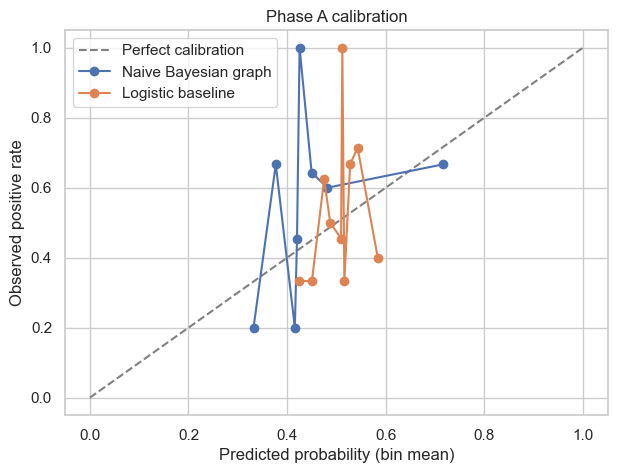

In [11]:
# Calibration curves on Phase A test split
cal_graph = phase_a_result['calibration_graph']
cal_log = phase_a_result['calibration_logistic']

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(cal_graph['pred_bin_mean'], cal_graph['true_rate'], marker='o', label='Naive Bayesian graph')
plt.plot(cal_log['pred_bin_mean'], cal_log['true_rate'], marker='o', label='Logistic baseline')
plt.xlabel('Predicted probability (bin mean)')
plt.ylabel('Observed positive rate')
plt.title('Phase A calibration')
plt.legend()
plt.show()


In [12]:
# Phase B: product labels source (reuse original experiment artifacts where possible)
phase_b_reused = False
phase_b_source = None
if REUSE_PHASE_B_LABELS and REUSE_PHASE_B_SCORED_PATH.exists():
    phase_b_labeled = pd.read_csv(REUSE_PHASE_B_SCORED_PATH)
    required_cols = [
        'record_id',
        'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
        'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
        'overall_confidence'
    ]
    missing_cols = [c for c in required_cols if c not in phase_b_labeled.columns]
    if missing_cols:
        raise ValueError(f'Reused Phase B artifact missing required label columns: {missing_cols}')
    phase_b_reused = True
    phase_b_source = 'reused_from_experiment_trust_phase_b_scored'
    phase_b_rows_loaded = int(len(phase_b_labeled))
    print('Phase B labels reused from:', REUSE_PHASE_B_SCORED_PATH)
    print('Reused Phase B rows:', phase_b_rows_loaded)
else:
    phase_b_df = load_product_dataset(
        product_csv_path=PRODUCT_DATASET_PATH,
        target_rows=PHASE_B_TARGET_ROWS,
        random_state=RANDOM_STATE,
    )
    phase_b_source = 'fresh_product_load'
    phase_b_rows_loaded = int(len(phase_b_df))
    print('Phase B rows loaded from product CSV:', phase_b_rows_loaded)
    display(phase_b_df[['record_id', 'PRODUCT_ID', 'PRODUCT_TYPE_ID', 'TITLE']].head(5))


Phase B labels reused from: /Users/lohzh/Desktop/cs3263-repo/experiment_trust/artifacts/llm_trust_graph/phase_b_scored.csv
Reused Phase B rows: 120


In [13]:
# Phase B: LLM labeling (skipped when reused labels are available)
if phase_b_reused:
    print('Skipping Phase B LLM labeling; using reused labels from original experiment artifacts.')
else:
    phase_b_labeled = label_dataframe_with_ollama(
        phase_b_df,
        id_col='record_id',
        text_col='text',
        domain='product',
        cache_path=phase_b_cache,
        config=label_config,
        max_rows=PHASE_B_TARGET_ROWS,
        max_calls=MAX_CALLS_PER_PHASE,
    )
phase_b_display_cols = [
    'record_id',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'overall_confidence'
]
print('Phase B labeled rows:', len(phase_b_labeled))
if len(phase_b_labeled) == 0:
    print('No Phase B labeled rows available.')
else:
    missing_cols = [c for c in phase_b_display_cols if c not in phase_b_labeled.columns]
    if missing_cols:
        print('Missing columns in labeled output:', missing_cols)
    available_cols = [c for c in phase_b_display_cols if c in phase_b_labeled.columns]
    display(phase_b_labeled[available_cols].head(10))


Skipping Phase B LLM labeling; using reused labels from original experiment artifacts.
Phase B labeled rows: 120


,record_id,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,overall_confidence
0,659984,0.25,0.75,0.25,0.5,0.5,0.75,0.5,0.80
1,433902,0.50,0.50,0.50,0.5,0.5,0.50,0.5,0.80
2,1499195,0.60,0.40,0.20,0.7,0.8,0.90,0.5,0.80
3,2641984,0.60,0.80,0.20,0.9,0.7,0.50,0.4,0.80
4,154989,1.00,1.00,0.00,1.0,1.0,1.00,1.0,0.90
5,346570,0.50,1.00,0.00,0.5,0.5,0.50,0.5,0.80
6,2067198,0.80,0.90,0.10,0.7,0.6,0.50,0.8,0.85
7,373253,0.50,0.50,0.50,0.5,0.5,0.50,0.5,0.80
8,2536585,0.20,0.80,0.40,0.6,0.4,0.30,0.5,0.85
9,1578439,0.60,0.80,0.20,0.7,0.9,0.50,0.4,0.80


In [14]:
# Phase B inference (no truth labels): trust-risk indices
phase_b_scored = apply_phase_b_inference(
    phase_b_labeled,
    graph_model=graph_model,
    logistic_model=logistic_model,
)

display(
    phase_b_scored[[
        'record_id', 'PRODUCT_ID', 'PRODUCT_TYPE_ID',
        'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
        'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
        'trust_risk_index_graph', 'graph_uncertainty_entropy'
    ]]
    .sort_values('trust_risk_index_graph', ascending=False)
    .head(15)
)


,record_id,PRODUCT_ID,PRODUCT_TYPE_ID,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,trust_risk_index_graph,graph_uncertainty_entropy
24,130441,130441,40,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.835278,0.645487
65,219495,219495,1,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.835278,0.645487
1,433902,433902,114,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.835278,0.645487
7,373253,373253,12743,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.835278,0.645487
76,714413,714413,225,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.835278,0.645487
85,567741,567741,1,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.835278,0.645487
73,796767,796767,742,0.5,0.5,0.0,0.5,0.5,0.5,0.5,0.727436,0.845120
20,1390409,1390409,11931,0.8,0.7,0.4,0.9,0.6,0.5,0.8,0.724031,0.849901
2,1499195,1499195,8501,0.6,0.4,0.2,0.7,0.8,0.9,0.5,0.722530,0.851981
84,48855,48855,6317,0.5,0.5,0.2,0.8,0.9,0.7,0.6,0.722530,0.851981


In [15]:
# Save outputs
phase_a_labeled_path = artifacts_dir / 'phase_a_labeled.csv'
phase_a_metrics_path = artifacts_dir / 'phase_a_metrics.csv'
phase_a_cal_graph_path = artifacts_dir / 'phase_a_calibration_graph.csv'
phase_a_cal_log_path = artifacts_dir / 'phase_a_calibration_logistic.csv'
phase_b_scored_path = artifacts_dir / 'phase_b_scored.csv'
phase_a_dup_path = artifacts_dir / 'phase_a_duplicate_check.csv'
phase_a_labeled.to_csv(phase_a_labeled_path, index=False)
metrics_df.to_csv(phase_a_metrics_path, index=False)
phase_a_result['calibration_graph'].to_csv(phase_a_cal_graph_path, index=False)
phase_a_result['calibration_logistic'].to_csv(phase_a_cal_log_path, index=False)
phase_b_scored.to_csv(phase_b_scored_path, index=False)
if len(phase_a_dup):
    phase_a_dup.to_csv(phase_a_dup_path, index=False)
graph_model_json = {
    'class_probs': {str(k): float(v) for k, v in graph_model['class_probs'].items()},
    'cpds': {
        col: {str(cls): probs for cls, probs in class_map.items()}
        for col, class_map in graph_model['cpds'].items()
    },
    'bucket_columns': graph_model.get('bucket_columns', []),
}
save_json(artifacts_dir / 'graph_model.json', graph_model_json)
run_info = {
    'ollama_model': OLLAMA_MODEL,
    'fake_reviews_dataset_path': str(FAKE_REVIEWS_DATASET_PATH),
    'product_dataset_path': str(PRODUCT_DATASET_PATH),
    'phase_b_reused': bool(phase_b_reused),
    'phase_b_source': phase_b_source,
    'phase_b_reuse_source_path': str(REUSE_PHASE_B_SCORED_PATH) if phase_b_reused else None,
    'phase_a_rows_loaded': int(len(phase_a_df)),
    'phase_a_rows_labeled': int(len(phase_a_labeled)),
    'phase_b_rows_loaded': int(phase_b_rows_loaded),
    'phase_b_rows_labeled': int(len(phase_b_labeled)),
    'max_calls_per_phase': MAX_CALLS_PER_PHASE,
    'metrics': metrics_df.to_dict(orient='records'),
    'artifacts': {
        'phase_a_labeled': str(phase_a_labeled_path),
        'phase_a_metrics': str(phase_a_metrics_path),
        'phase_a_calibration_graph': str(phase_a_cal_graph_path),
        'phase_a_calibration_logistic': str(phase_a_cal_log_path),
        'phase_b_scored': str(phase_b_scored_path),
        'graph_model': str(artifacts_dir / 'graph_model.json'),
        'phase_a_duplicate_check': str(phase_a_dup_path) if len(phase_a_dup) else None,
    },
}
save_json(artifacts_dir / 'run_info.json', run_info)
print('Saved artifacts:')
for key, path in run_info['artifacts'].items():
    if path:
        print(f' - {key}: {path}')


Saved artifacts:
 - phase_a_labeled: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/phase_a_labeled.csv
 - phase_a_metrics: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/phase_a_metrics.csv
 - phase_a_calibration_graph: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/phase_a_calibration_graph.csv
 - phase_a_calibration_logistic: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/phase_a_calibration_logistic.csv
 - phase_b_scored: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/phase_b_scored.csv
 - graph_model: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/graph_model.json
 - phase_a_duplicate_check: /Users/lohzh/Desktop/cs3263-repo/experiment_trust_fake_reviews/artifacts/llm_trust_graph/phase_a_duplicate_check.csv


## Notes
- Re-running the notebook reuses cached labels in `phase_a_labels.jsonl` and `phase_b_labels.jsonl`.
- Increase `PHASE_A_TARGET_ROWS`, `PHASE_B_TARGET_ROWS`, and `MAX_CALLS_PER_PHASE` for larger runs.
- For strict validation, set `FAKE_NEWS_LOCAL_PATH` to a known dataset and keep synthetic fallback only for smoke tests.


## Stage Visualizations

The cells below visualize each stage of the pipeline from raw LLM labels to BN-adjusted outcomes.


### Visualization 1: Fake-News LLM Label Distributions

This plot shows how raw LLM trust labels differ between true and fake news items. If the labeling is useful, true items should generally have higher claim/signal/CBIP scores and fake items should have higher heuristic pressure.


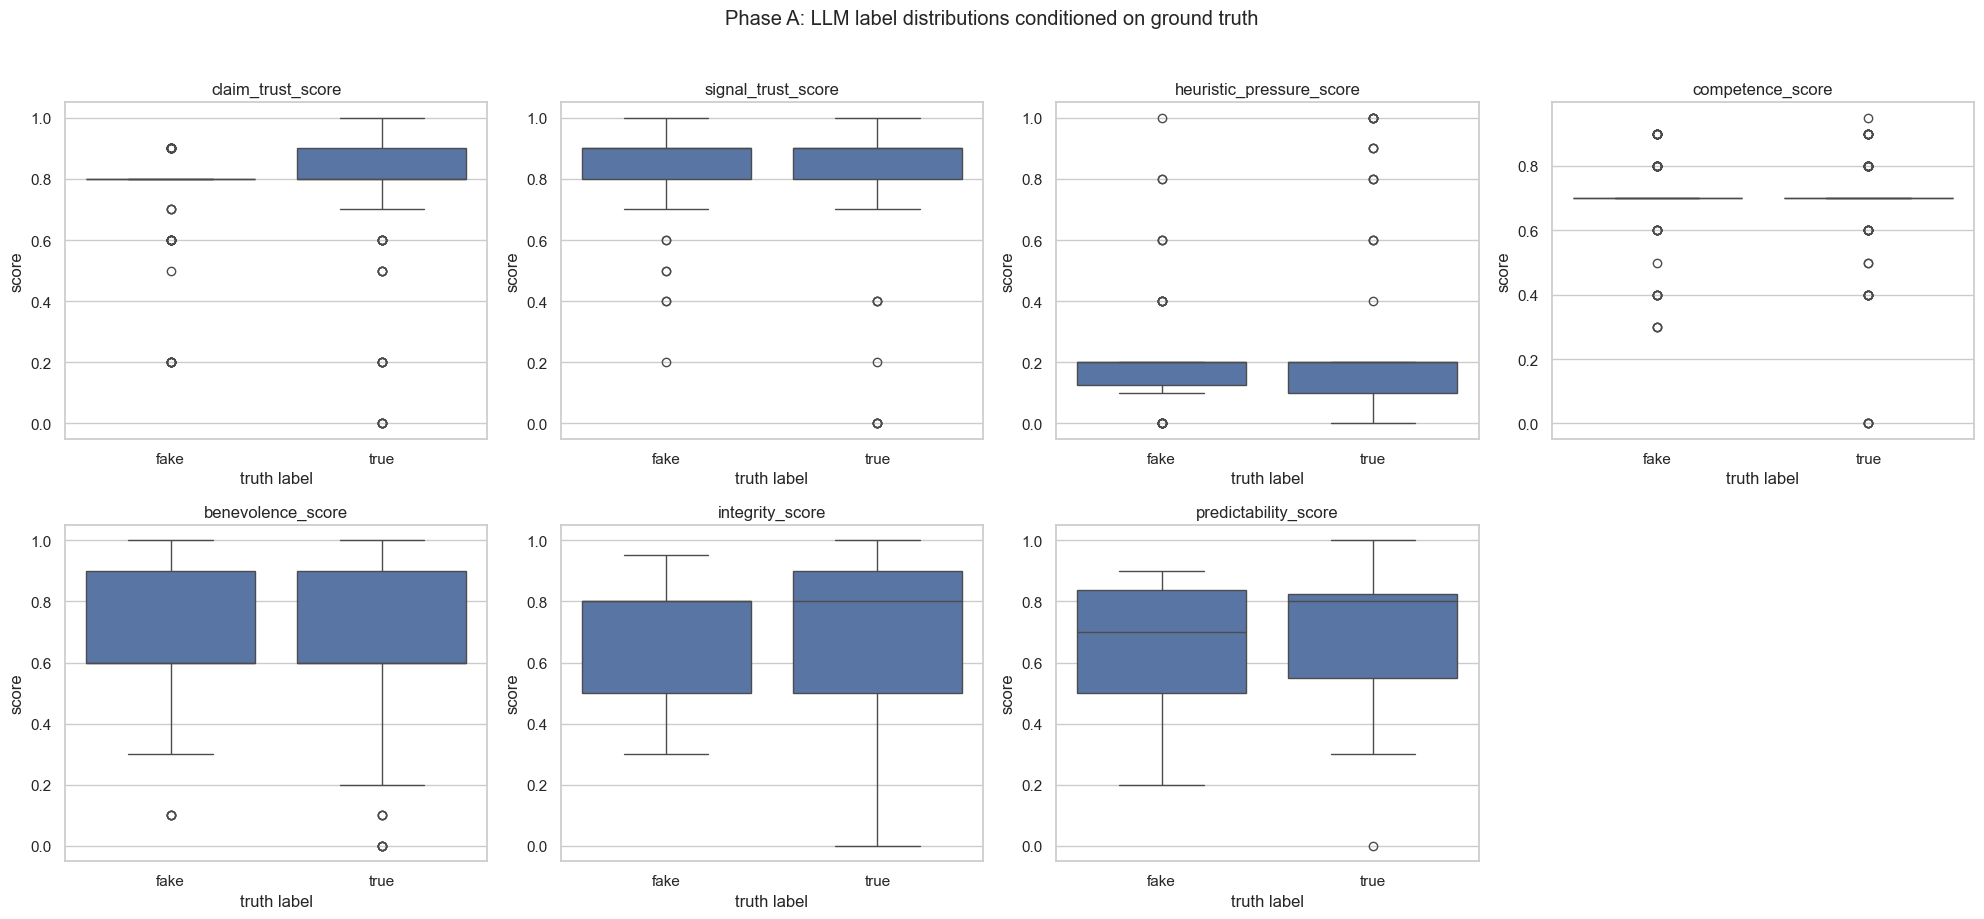

In [16]:
# 1) Phase A (Fake News): Raw LLM label distributions vs truth
phase_a_metrics = [
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score'
]
phase_a_plot_df = phase_a_labeled.copy()
phase_a_plot_df['label_truth_name'] = phase_a_plot_df['label_truth'].map({0: 'fake', 1: 'true'})
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, metric in zip(axes.flatten(), phase_a_metrics):
    sns.boxplot(data=phase_a_plot_df, x='label_truth_name', y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('truth label')
    ax.set_ylabel('score')
# Hide the 8th empty panel
axes.flatten()[-1].axis('off')
plt.suptitle('Phase A: LLM label distributions conditioned on ground truth', y=1.02)
plt.tight_layout()
plt.show()


### Visualization 2: Fake-News BN-Adjusted Outcomes

This view compares model-adjusted outputs on the held-out fake-news test set. You can see class separation for BN and logistic posteriors, and whether both models agree on the same examples (scatter near diagonal).


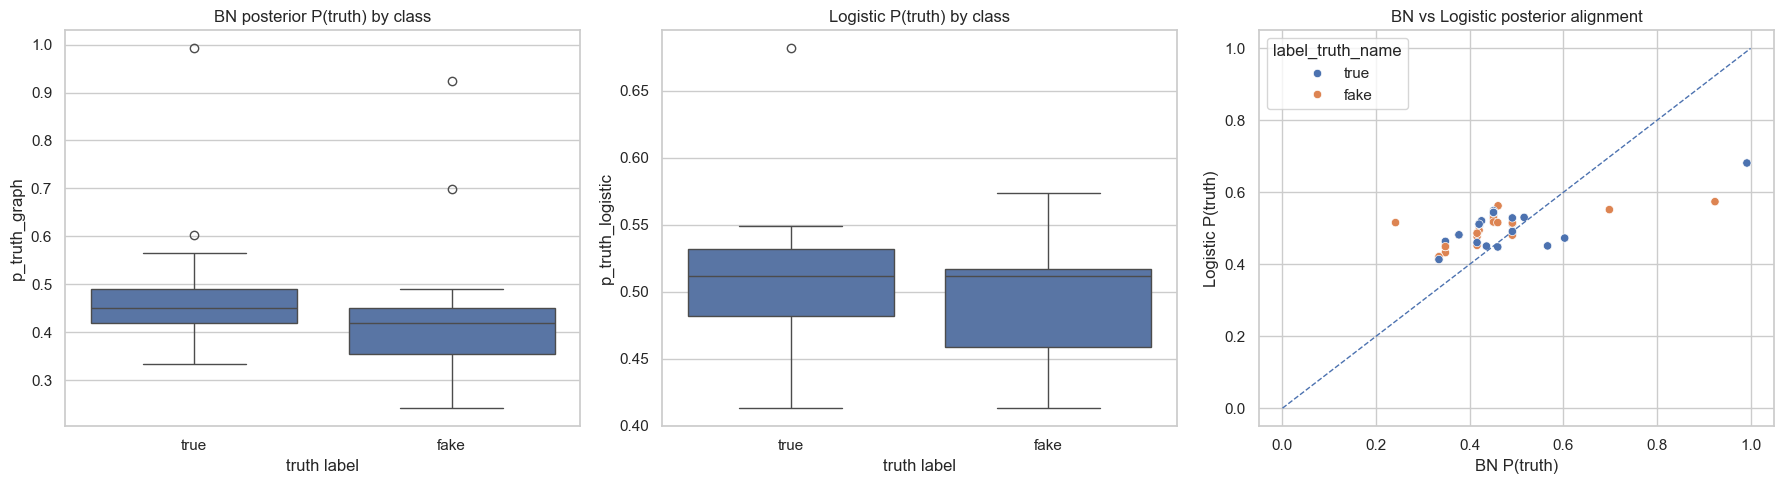

,model,auc,brier,log_loss
0,naive_bayes_graph,0.666667,0.248826,0.698466
1,logistic_baseline,0.569444,0.245362,0.683645


In [17]:
# 2) Phase A (Fake News): BN/logistic adjusted outcomes on held-out test split
phase_a_test_vis = phase_a_result['test_df'].copy()
phase_a_test_vis['p_truth_graph'] = phase_a_result['test_pred_graph']
phase_a_test_vis['p_truth_logistic'] = phase_a_result['test_pred_logistic']
phase_a_test_vis['risk_graph'] = 1.0 - phase_a_test_vis['p_truth_graph']
phase_a_test_vis['risk_logistic'] = 1.0 - phase_a_test_vis['p_truth_logistic']
phase_a_test_vis['label_truth_name'] = phase_a_test_vis['label_truth'].map({0: 'fake', 1: 'true'})
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=phase_a_test_vis, x='label_truth_name', y='p_truth_graph', ax=axes[0])
axes[0].set_title('BN posterior P(truth) by class')
axes[0].set_xlabel('truth label')
sns.boxplot(data=phase_a_test_vis, x='label_truth_name', y='p_truth_logistic', ax=axes[1])
axes[1].set_title('Logistic P(truth) by class')
axes[1].set_xlabel('truth label')
sns.scatterplot(
    data=phase_a_test_vis,
    x='p_truth_graph',
    y='p_truth_logistic',
    hue='label_truth_name',
    ax=axes[2],
)
axes[2].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[2].set_title('BN vs Logistic posterior alignment')
axes[2].set_xlabel('BN P(truth)')
axes[2].set_ylabel('Logistic P(truth)')
plt.tight_layout()
plt.show()
display(phase_a_result['metrics'])


### Visualization 3: Product Raw LLM Label Distributions

This plot summarizes how the LLM labels the product dataset before any BN adjustment. It gives the baseline label shape (e.g., where scores cluster and whether pressure is high/low overall).


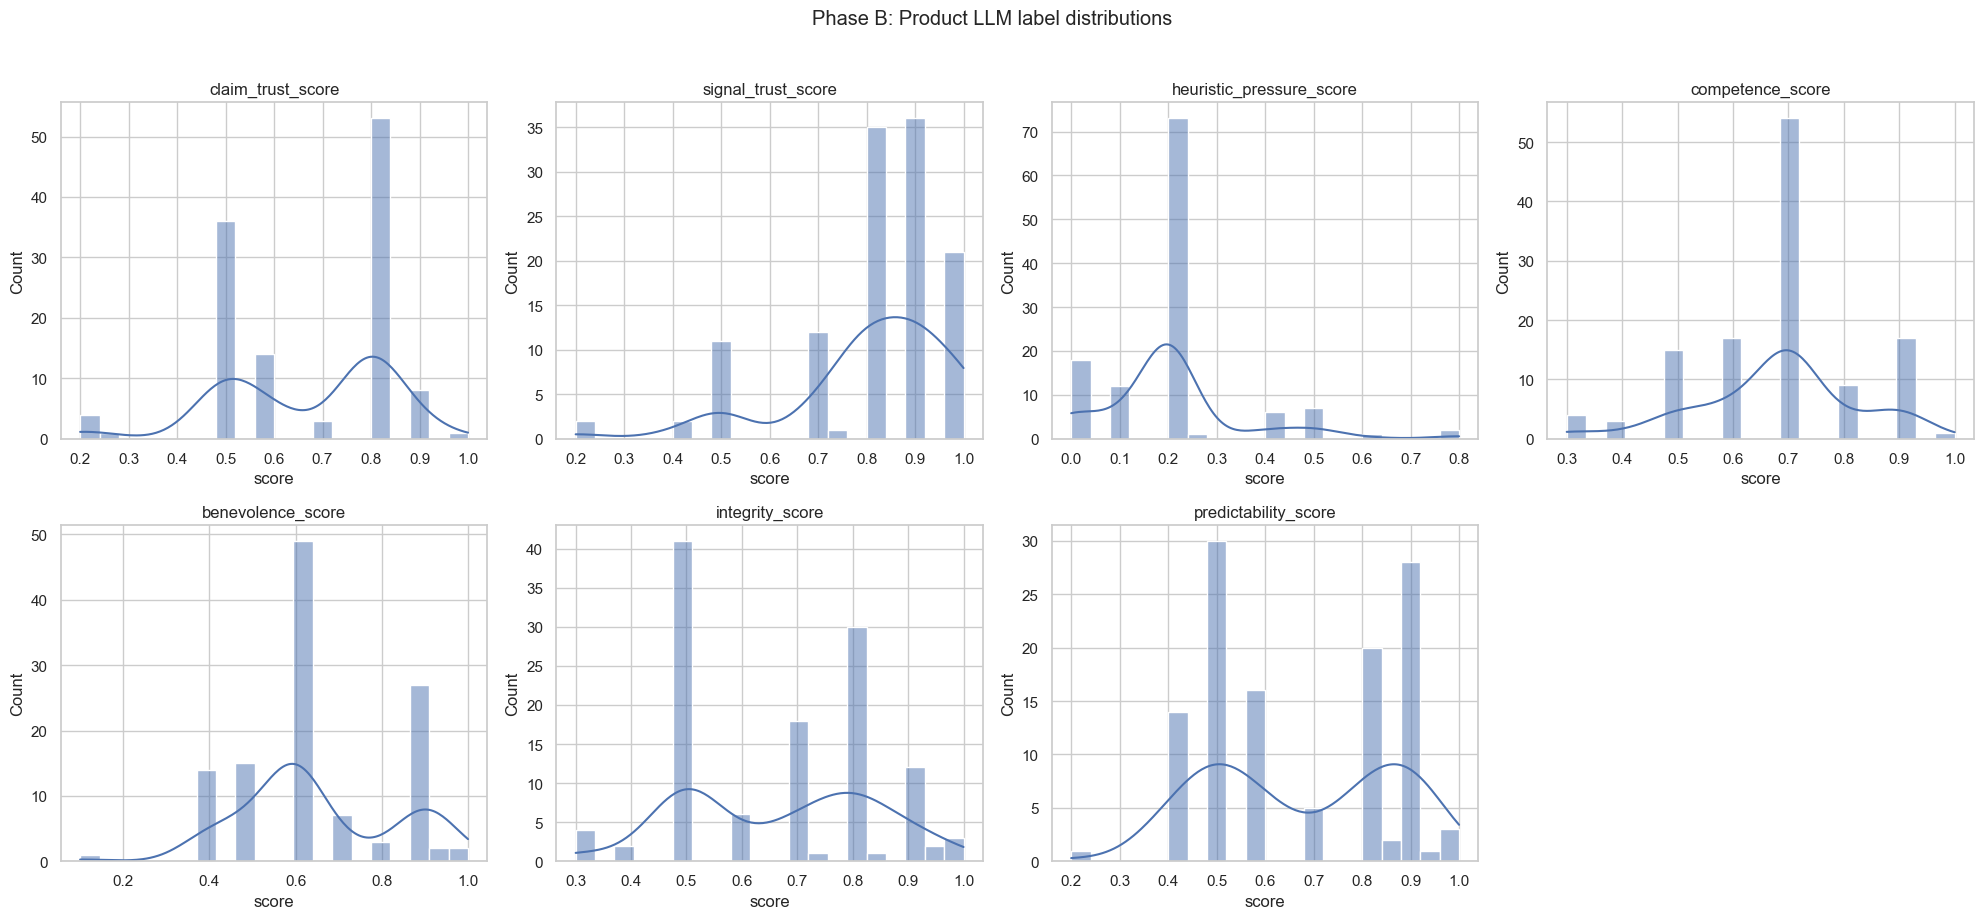

In [18]:
# 3) Phase B (Products): Raw LLM label distributions
phase_b_metrics = [
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score'
]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, metric in zip(axes.flatten(), phase_b_metrics):
    sns.histplot(phase_b_labeled[metric], bins=20, kde=True, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('score')
axes.flatten()[-1].axis('off')
plt.suptitle('Phase B: Product LLM label distributions', y=1.02)
plt.tight_layout()
plt.show()


### Visualization 4: Product BN-Adjusted Outcomes

This view shows BN-adjusted truth likelihood, derived trust-risk index, and uncertainty entropy for products. Use it to understand how calibration changes raw labels and where predictions remain uncertain.


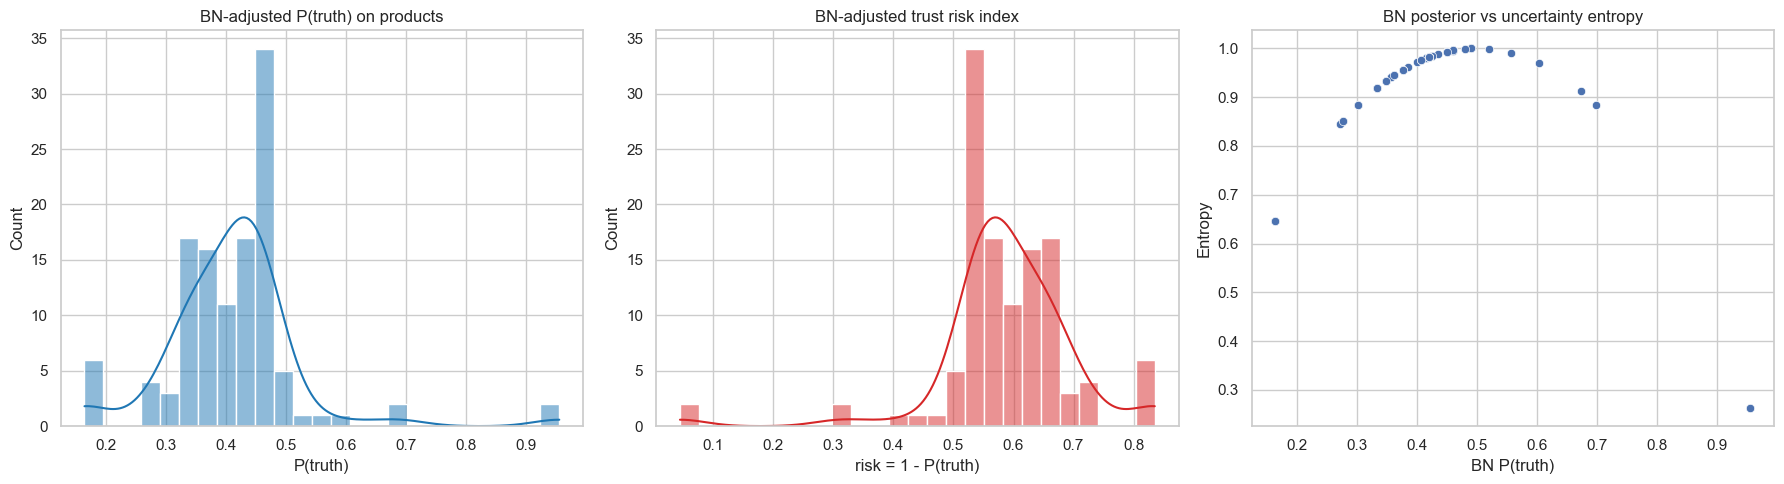

In [19]:
# 4) Phase B (Products): BN/logistic adjusted outcomes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(phase_b_scored['phase_b_truth_likelihood_graph'], bins=25, kde=True, ax=axes[0], color='tab:blue')
axes[0].set_title('BN-adjusted P(truth) on products')
axes[0].set_xlabel('P(truth)')
sns.histplot(phase_b_scored['trust_risk_index_graph'], bins=25, kde=True, ax=axes[1], color='tab:red')
axes[1].set_title('BN-adjusted trust risk index')
axes[1].set_xlabel('risk = 1 - P(truth)')
sns.scatterplot(
    data=phase_b_scored,
    x='phase_b_truth_likelihood_graph',
    y='graph_uncertainty_entropy',
    ax=axes[2],
)
axes[2].set_title('BN posterior vs uncertainty entropy')
axes[2].set_xlabel('BN P(truth)')
axes[2].set_ylabel('Entropy')
plt.tight_layout()
plt.show()


### Visualization 5: BN Graph and Example Product Explanations

This cell first visualizes the BN dependency structure used for adjustment, then lists 3 representative products (low/median/high BN truth likelihood) with both raw LLM labels and BN-adjusted outcomes for interpretability.


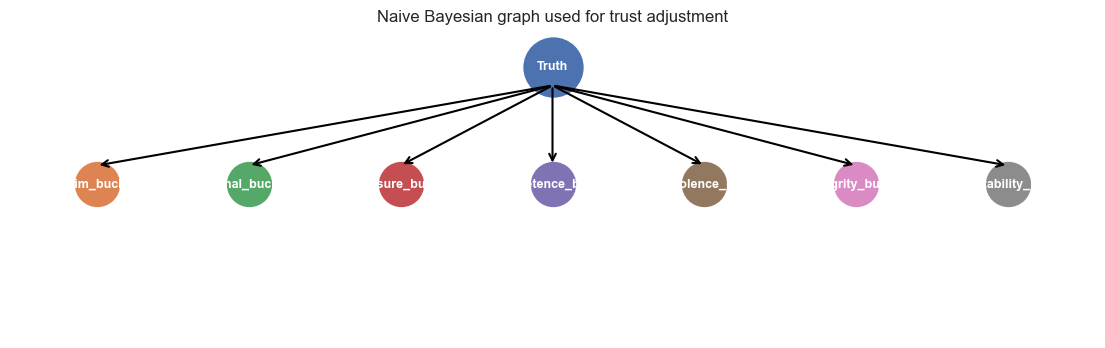

,record_id,TITLE,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,phase_b_truth_likelihood_graph,trust_risk_index_graph,graph_uncertainty_entropy
0,433902,Fractured Reality,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.164722,0.835278,0.645487
60,2067198,iKraft Mouse Pad 18x22cm Non-Slip Rubber | Printed Gaming Mouse Pad Mate for Home Office (,0.8,0.9,0.1,0.7,0.6,0.5,0.8,0.420020,0.579980,0.981463
119,260809,"H Ristiyanl K Taslaklar: Ke I, Arnavutluk Katolik Kilisesi, Religious Society of Friends,",0.5,0.2,0.8,0.4,0.6,0.3,0.5,0.955468,0.044532,0.262697


In [20]:
# 5) BN structure + 3 sample product records (LLM labels and BN-adjusted outcomes)
# Simple BN structure visualization used in this notebook:
# Truth -> {claim_bucket, signal_bucket, pressure_bucket, competence_bucket, benevolence_bucket, integrity_bucket, predictability_bucket}
bn_nodes = [
    'Truth',
    'claim_bucket', 'signal_bucket', 'pressure_bucket',
    'competence_bucket', 'benevolence_bucket', 'integrity_bucket', 'predictability_bucket'
]
pos = {
    'Truth': (0.5, 0.88),
    'claim_bucket': (0.08, 0.50),
    'signal_bucket': (0.22, 0.50),
    'pressure_bucket': (0.36, 0.50),
    'competence_bucket': (0.50, 0.50),
    'benevolence_bucket': (0.64, 0.50),
    'integrity_bucket': (0.78, 0.50),
    'predictability_bucket': (0.92, 0.50),
}
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
for node in bn_nodes:
    x, y = pos[node]
    ax.scatter([x], [y], s=1800 if node == 'Truth' else 1000, zorder=3)
    ax.text(x, y, node, ha='center', va='center', color='white', fontsize=9, fontweight='bold', zorder=4)
for child in bn_nodes[1:]:
    x1, y1 = pos['Truth']
    x2, y2 = pos[child]
    ax.annotate('', xy=(x2, y2 + 0.06), xytext=(x1, y1 - 0.06),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.set_title('Naive Bayesian graph used for trust adjustment')
plt.show()
# Pick 3 representative products: lowest, median, highest BN truth likelihood
ordered = phase_b_scored.sort_values('phase_b_truth_likelihood_graph').reset_index(drop=True)
if len(ordered) >= 3:
    idxs = [0, len(ordered) // 2, len(ordered) - 1]
else:
    idxs = list(range(len(ordered)))
sample_products = ordered.iloc[idxs].copy()
sample_cols = [
    'record_id',
    'TITLE',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'phase_b_truth_likelihood_graph', 'trust_risk_index_graph', 'graph_uncertainty_entropy'
]
sample_cols = [c for c in sample_cols if c in sample_products.columns]
if 'TITLE' in sample_products.columns:
    sample_products['TITLE'] = sample_products['TITLE'].astype(str).str.slice(0, 90)
display(sample_products[sample_cols])


### Visualization 6: High/Low News Samples Per Trust Factor

This cell selects one fake-news record with the highest score and one with the lowest score for each of the 7 factors (14 rows total target). It helps you audit what the label extremes look like in actual text.


In [21]:
# 6) Phase A: high/low sample news per factor (14 rows target)
factors = [
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score'
]
news_cols = ['record_id', 'label_truth', 'text'] + factors
news_cols = [c for c in news_cols if c in phase_a_labeled.columns]
phase_a_base = phase_a_labeled[news_cols].copy()
rows = []
for factor in factors:
    if factor not in phase_a_base.columns:
        continue
    high_idx = phase_a_base[factor].idxmax()
    low_idx = phase_a_base[factor].idxmin()
    high_row = phase_a_base.loc[high_idx].copy()
    high_row['factor'] = factor
    high_row['extreme'] = 'high'
    high_row['selected_score'] = float(high_row[factor])
    low_row = phase_a_base.loc[low_idx].copy()
    low_row['factor'] = factor
    low_row['extreme'] = 'low'
    low_row['selected_score'] = float(low_row[factor])
    rows.append(high_row)
    rows.append(low_row)
extremes_df = pd.DataFrame(rows).reset_index(drop=True)
if 'text' in extremes_df.columns:
    extremes_df['text_preview'] = extremes_df['text'].astype(str).str.slice(0, 180)
display_cols = [
    'factor', 'extreme', 'record_id', 'label_truth', 'selected_score',
    'claim_trust_score', 'signal_trust_score', 'heuristic_pressure_score',
    'competence_score', 'benevolence_score', 'integrity_score', 'predictability_score',
    'text_preview'
]
display_cols = [c for c in display_cols if c in extremes_df.columns]
print('Requested rows: 14 | Returned rows:', len(extremes_df))
print('Unique records among selected rows:', extremes_df['record_id'].nunique() if 'record_id' in extremes_df.columns else 'N/A')
display(extremes_df[display_cols])


Requested rows: 14 | Returned rows: 14
Unique records among selected rows: 8


,factor,extreme,record_id,label_truth,selected_score,claim_trust_score,signal_trust_score,heuristic_pressure_score,competence_score,benevolence_score,integrity_score,predictability_score,text_preview
0,claim_trust_score,high,fake_reviews_141,1,1.00,1.0,0.8,0.0,0.90,0.95,0.95,1.00,Great story!! I enjoyed the development of the characters and can't wait to see how Sophia and Marc handle taking their relationship to ...
1,claim_trust_score,low,fake_reviews_146,1,0.00,0.0,0.0,1.0,0.00,0.00,0.00,0.50,Does a great job. What a difference in my tank\n\n Teddie
2,signal_trust_score,high,fake_reviews_1,0,1.00,0.9,1.0,0.0,0.80,0.90,0.95,0.85,"LT&T did not disappoint. We have the characters we love in this book, and the way the author is able to make them fit into the story. ..."
3,signal_trust_score,low,fake_reviews_146,1,0.00,0.0,0.0,1.0,0.00,0.00,0.00,0.50,Does a great job. What a difference in my tank\n\n Teddie
4,heuristic_pressure_score,high,fake_reviews_37,0,1.00,0.2,0.8,1.0,0.60,0.40,0.30,0.50,Beautiful love story with a happy ending. Great job!!!\n\nI received this book from the
5,heuristic_pressure_score,low,fake_reviews_1,0,0.00,0.9,1.0,0.0,0.80,0.90,0.95,0.85,"LT&T did not disappoint. We have the characters we love in this book, and the way the author is able to make them fit into the story. ..."
6,competence_score,high,fake_reviews_218,1,0.95,0.8,0.9,0.2,0.95,0.85,0.90,0.80,"This really isn't even the same tool as the 2-ton cable puller. I mean it is, but this thing is MASSIVE. It weighs about 35 pounds and..."
7,competence_score,low,fake_reviews_146,1,0.00,0.0,0.0,1.0,0.00,0.00,0.00,0.50,Does a great job. What a difference in my tank\n\n Teddie
8,benevolence_score,high,fake_reviews_90,0,1.00,0.8,0.6,0.2,0.90,1.00,0.70,0.80,Very nice product! Much better than the stock Garmin.works great.Nice little speaker! Works great.
9,benevolence_score,low,fake_reviews_146,1,0.00,0.0,0.0,1.0,0.00,0.00,0.00,0.50,Does a great job. What a difference in my tank\n\n Teddie
